# FDSF数据区分能力演示

In [3]:
import pandas as pd
import numpy as np
from common import *
from JDistance import CJDistance
from JSample import CJSample
import seaborn as sns
from tqdm.notebook import tqdm
from warnings import filterwarnings
import matplotlib.pyplot as plt
filterwarnings("ignore") 
np.set_printoptions(suppress=True)
pd.set_option('display.float_format',lambda x : '%.8f' % x)
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 读取样本

In [4]:
all_dataset = {}
for i in range(9):
    df_tmp = pd.read_csv("%s%s"%(g_sample_path,"%d.csv"%i),index_col=0)
    #df_tmp=df_tmp[['src_port','label']]
    tmp = df_tmp.groupby("label").count()['duration']
    normal = tmp[0]
    abnormal = tmp[1]
    normal_rate = normal/(normal+abnormal)
    abnormal_rate = abnormal/(normal+abnormal)
    all_dataset[str(i)] = df_tmp
    print("reading",i,"normal:%0.2f(%d)"%(normal_rate,normal),"abnormal:%0.2f(%d)"%(abnormal_rate,abnormal))

reading 0 normal:0.13(102081) abnormal:0.87(710489)
reading 1 normal:0.24(191465) abnormal:0.76(621105)
reading 2 normal:0.34(273601) abnormal:0.66(538969)
reading 3 normal:0.43(350103) abnormal:0.57(462467)
reading 4 normal:0.52(424938) abnormal:0.48(387632)
reading 5 normal:0.61(498332) abnormal:0.39(314238)
reading 6 normal:0.71(573223) abnormal:0.29(239347)
reading 7 normal:0.80(648744) abnormal:0.20(163826)
reading 8 normal:0.90(728298) abnormal:0.10(84272)


# 显示热力图函数

In [5]:
def show_heatmap(df):
    plt.style.use({'figure.figsize':(16, 6)})
    plt.ticklabel_format(style='plain',axis='both')
    sns.set(font_scale=1.5)
    cmap = sns.cubehelix_palette(start = 1, rot = 3, gamma=0.8, as_cmap = True)
    sns.heatmap(df, cmap = cmap, linewidths = 0.05,annot=False, fmt="g",annot_kws={"fontsize":32})

# 将两组数据放到一起，计算直方图

In [6]:
def GetHistogram(df1,df2,bin_count=100):
    df_tmp1 = df1.copy( deep = True )
    df_tmp2 = df2.copy( deep = True )
    df_tmp = pd.concat([df_tmp1,df_tmp2],ignore_index = False)
    df_tmp = CJSample.Preprocess(df_tmp).fillna(0)
    
    ret_df = pd.DataFrame()
    ret_df1 = pd.DataFrame()
    ret_df2 = pd.DataFrame()
    ret_s1 = pd.Series()
    ret_s2 = pd.Series()
    for key in df_tmp.keys():
        if key in ['label']:
            continue
        #使用平滑降噪
        if key in ['in_bytes','out_bytes','in_pkts','out_pkts','duration']:
            #diff = df_tmp[key].max() - df_tmp[key].min()
            sli_window = int(np.sqrt(df_tmp.shape[0])) + 1
            #sli_window = int(np.log2(df_tmp.shape[0]))+1 #//(2*bin_count)
            #sli_window = df_tmp.shape[0]//( bin_count * bin_count )
        else:
            sli_window = 1   
        #sli_window = int(np.sqrt(df_tmp.shape[0])) + 1
        df_tmp[key] = df_tmp[key].rolling(window=sli_window).mean()
        df_tmp[key] = df_tmp[key].fillna(0)
        #重新对其赋值
        tmp = df_tmp[key].head(df_tmp1.shape[0]+sli_window-1)        
        df_tmp1[key] = tmp.tail(df_tmp1.shape[0]).values
        tmp = df_tmp[key].tail(df_tmp2.shape[0])
        df_tmp2[key] = tmp
        #统一划分bin
        hist, bin_edges = np.histogram( df_tmp[key], bins = bin_count )
        hist1, bin_edges1 = np.histogram( df_tmp1[key], bins = bin_edges )
        hist2, bin_edges2 = np.histogram( df_tmp2[key], bins = bin_edges )
        #输出结果
        ret_df[key] = pd.Series(hist)
        ret_df1[key] = pd.Series(hist1)
        ret_df1[key] = ( ret_df1[key] - ret_df1[key].min() ) / ( ret_df1[key].max() - ret_df1[key].min() )
        ret_s1 = ret_s1.append(ret_df1[key], ignore_index=True)

        ret_df2[key] = pd.Series(hist2)
        ret_df2[key] = (ret_df2[key] - ret_df2[key].min()) / ( ret_df2[key].max() - ret_df2[key].min() )
        ret_s2 = ret_s2.append(ret_df2[key], ignore_index=True)

    return ret_df1.T,ret_s1,ret_df2.T,ret_s2

def CalcDistance(df1, df2, bin_count = 100 ):
    df_tmp1,s1,df_tmp2,s2 = GetHistogram(df1,df2,bin_count)
    ret = []
    for key in df_tmp1.T:
        ds1 = df_tmp1.T[key]
        ds2 = df_tmp2.T[key]
        s = CJDistance(ds1.tolist(),ds2.tolist())
        tmp = {}
        tmp["Feature"] = key
        tmp['Cosine'] = s.Cosine()
        tmp['Pearson'] = s.Pearson()
        tmp['Euclidean'] = s.Euclidean()
        tmp['EMD'] = s.EDM()
        tmp['KS'] = s.KSTest()[1]
        tmp['Manhattan'] = s.Manhattan()
        tmp['Minkowski'] = s.Minkowski()
        tmp['Jaccard'] = s.Jaccard()
        tmp['Entropy'] = s.Entropy()
        ret.append(tmp)
    return pd.DataFrame(ret)

# 计算直方图和距离演示

In [7]:
df1,s1,df2,s2 = GetHistogram(all_dataset['0'],all_dataset['2'])
display(df1)
d = CalcDistance(all_dataset['0'],all_dataset['2'])
display(d)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
src_port,0.40014782,0.00221729,0.00054201,0.00073910,0.00088692,0.00182311,0.00054201,0.00000000,0.00088692,0.00068983,...,0.90874600,0.89623060,0.93678246,0.12540034,0.06878542,0.10593742,0.04173442,0.08903671,0.10362158,0.06469574
dst_port,1.00000000,0.02286919,0.00607752,0.00975682,0.00463247,0.00600387,0.00347227,0.00355008,0.00444351,0.00560927,...,0.00028484,0.00042101,0.00038905,0.00019036,0.00029873,0.00005419,0.00014867,0.00006253,0.00031402,0.00041128
proto,0.00040795,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00003031,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.02585143
l7_proto,0.64214964,0.00057014,0.84906405,0.00000925,0.00045919,0.00033592,0.00022189,0.00019107,0.00005547,0.00020340,...,0.00000000,0.00016950,0.00000000,0.00004006,0.00000000,0.00029894,0.00000000,0.00000000,0.00034825,0.00000308
in_bytes,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00307705,1.00000000,0.07899417,0.03029309,0.01094162,...,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
out_bytes,0.00000000,0.00000000,0.00000000,0.00244981,1.00000000,0.70628350,0.06851155,0.01836346,0.00426415,0.00792651,...,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
in_pkts,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.05604251,1.00000000,0.04806859,0.03732757,0.03823251,...,0.00000000,0.00000455,0.00054342,0.00000000,0.00000000,0.00000000,0.00000000,0.00120734,0.00000000,0.00088902
out_pkts,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
duration,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,...,1.00000000,0.97434814,0.77255624,0.48721965,0.34148060,0.14842442,0.04784756,0.02077014,0.00661395,0.00159133
tcp_flags,0.07445416,0.00000000,0.00000000,0.00000000,0.20717679,0.00000000,0.00000000,0.00000000,0.00000000,0.00006081,...,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00050793


,Feature,Cosine,Pearson,Euclidean,EMD,KS,Manhattan,Minkowski,Jaccard,Entropy
0,src_port,0.98986567,0.98158049,1.15714793,0.06879107,0.00000175,7.48916909,0.68300000,0.01324503,0.22703958
1,dst_port,0.99753775,0.99788504,0.07051814,0.00280464,0.00000000,0.28057916,0.05700000,0.01098901,0.06068426
2,proto,0.99995954,0.99995956,0.00900358,0.00009700,1.00000000,0.00969970,0.00900000,0.25000000,0.00000000
3,l7_proto,0.94895371,0.94739412,0.46255806,0.00113481,0.00613403,0.79218519,0.40000000,0.02197802,0.25915232
4,in_bytes,0.14642788,0.12103748,1.35864387,0.00195934,0.99968923,2.70195028,1.18500000,0.02127660,0.00000000
5,out_bytes,0.46521370,0.45325112,1.25129754,0.00112112,0.90841050,2.13942620,1.10000000,0.05555556,0.39856502
6,in_pkts,0.11765985,0.09249246,1.37483624,0.00257735,0.99423563,2.73845891,1.19700000,0.01769912,0.14317688
7,out_pkts,0.05136564,0.00008321,2.03400789,0.00158973,0.21117009,6.13369594,1.49000000,0.02816901,0.77466038
8,duration,0.00013458,-0.10872428,3.23388183,0.01206915,1.00000000,14.32720664,2.05600000,0.04166667,0.00000000
9,tcp_flags,0.94054856,0.93799162,0.55730525,0.00848303,0.99968923,0.85671716,0.51400000,0.04761905,0.00000000


# 计算各种距离

In [8]:
bar = tqdm( total = len(all_dataset) * len(all_dataset))
all_distance = []
for i in all_dataset:
    df1 = all_dataset[i]
    for j in all_dataset:
        df2 = all_dataset[j]
        distance = CalcDistance(df1,df2,100)
        
        mask = ((distance['Feature']=='tcp_flags') | (distance['Feature']=='src_port') | (distance['Feature']=='dst_port') | (distance['Feature']=='proto') | (distance['Feature']=='l7_proto'))
        d = distance[mask]
        d = json.loads(d.mean().to_json())
        d['G1'] = int(i)
        d['G2'] = int(j)
        d['D'] = "discrete"
        all_distance.append(d)
        
        mask = ((distance['Feature']=='duration') | (distance['Feature']=='in_bytes') | (distance['Feature']=='out_bytes')| (distance['Feature']=='in_pkts') | (distance['Feature']=='out_pkts') )
        d = distance[mask]
        d = json.loads(d.mean().to_json())
        d['G1'] = int(i)
        d['G2'] = int(j)
        d['D'] = "continuous"
        all_distance.append(d)
        
        d = distance
        d = json.loads(d.mean().to_json())
        d['G1'] = int(i)
        d['G2'] = int(j)
        d['D'] = "all"
        all_distance.append(d)
        
        bar.update(1)
        
df_distance = pd.DataFrame(all_distance)

  0%|          | 0/81 [00:00<?, ?it/s]

In [9]:
df_distance

,Cosine,Pearson,Euclidean,EMD,KS,Manhattan,Minkowski,Jaccard,Entropy,G1,G2,D
0,1.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0,0,discrete
1,1.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0,0,continuous
2,1.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0,0,all
3,0.99453861,0.99401038,0.23570522,0.01020810,0.41092799,1.02213135,0.17500000,0.07545618,0.08234154,0,1,discrete
4,0.35361492,0.30845260,1.80627189,0.00698326,0.64029371,5.63968671,1.35300000,0.02648047,0.39416213,0,1,continuous
...,...,...,...,...,...,...,...,...,...,...,...,...
238,0.66920279,0.62958815,1.21045199,0.00675278,0.96266590,4.99972148,0.87720000,0.05162968,0.24272705,8,7,continuous
239,0.83152737,0.81156017,0.68382634,0.00660925,0.80960088,2.82426308,0.49740000,0.06189962,0.13060745,8,7,all
240,1.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,8,8,discrete
241,1.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,0.00000000,1.00000000,0.00000000,8,8,continuous


# 显示样本的距离

G2,0,1,2,3,4,5,6,7,8
G1,,,,,,,,,
0,0.000000,0.008596,0.010063,0.016540,0.022981,0.026756,0.029817,0.032284,0.037067
1,0.008594,0.000000,0.006249,0.011592,0.019327,0.022691,0.026750,0.030440,0.033431
2,0.010065,0.006250,0.000000,0.009690,0.016933,0.020124,0.025228,0.028201,0.033381
3,0.016541,0.011587,0.009695,0.000000,0.009921,0.014731,0.017503,0.021120,0.025076
4,0.022976,0.019321,0.016934,0.009921,0.000000,0.008165,0.011707,0.014094,0.019846
5,0.026744,0.022687,0.020127,0.014718,0.008161,0.000000,0.007003,0.010671,0.014764
6,0.029814,0.026742,0.025223,0.017496,0.011708,0.007022,0.000000,0.005297,0.009623
7,0.032282,0.030436,0.028197,0.021114,0.014093,0.010670,0.005300,0.000000,0.006607
8,0.037065,0.033427,0.033369,0.025072,0.019841,0.014757,0.009622,0.006609,0.000000


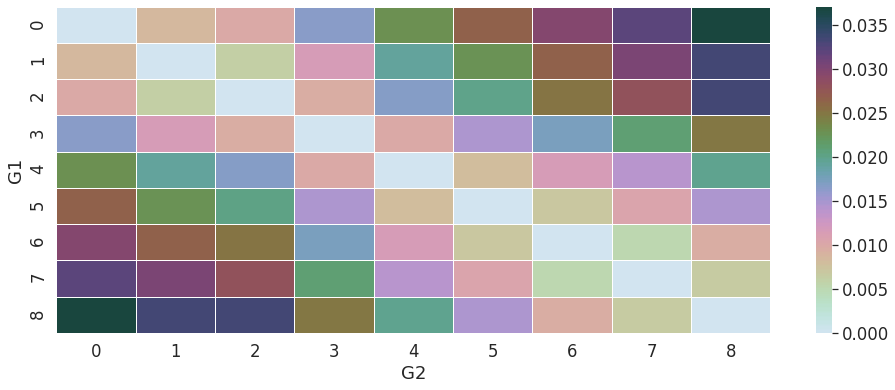

In [23]:
pd.set_option('display.float_format',lambda x : '%.6f' % x)
df_tmp = df_distance[df_distance['D']=='all'].sort_values(by=['G1'])
pt = df_tmp.pivot_table(index='G1', columns='G2',values='EMD',aggfunc=np.mean)
show_heatmap(pt)
pt

# 查看直方图演示

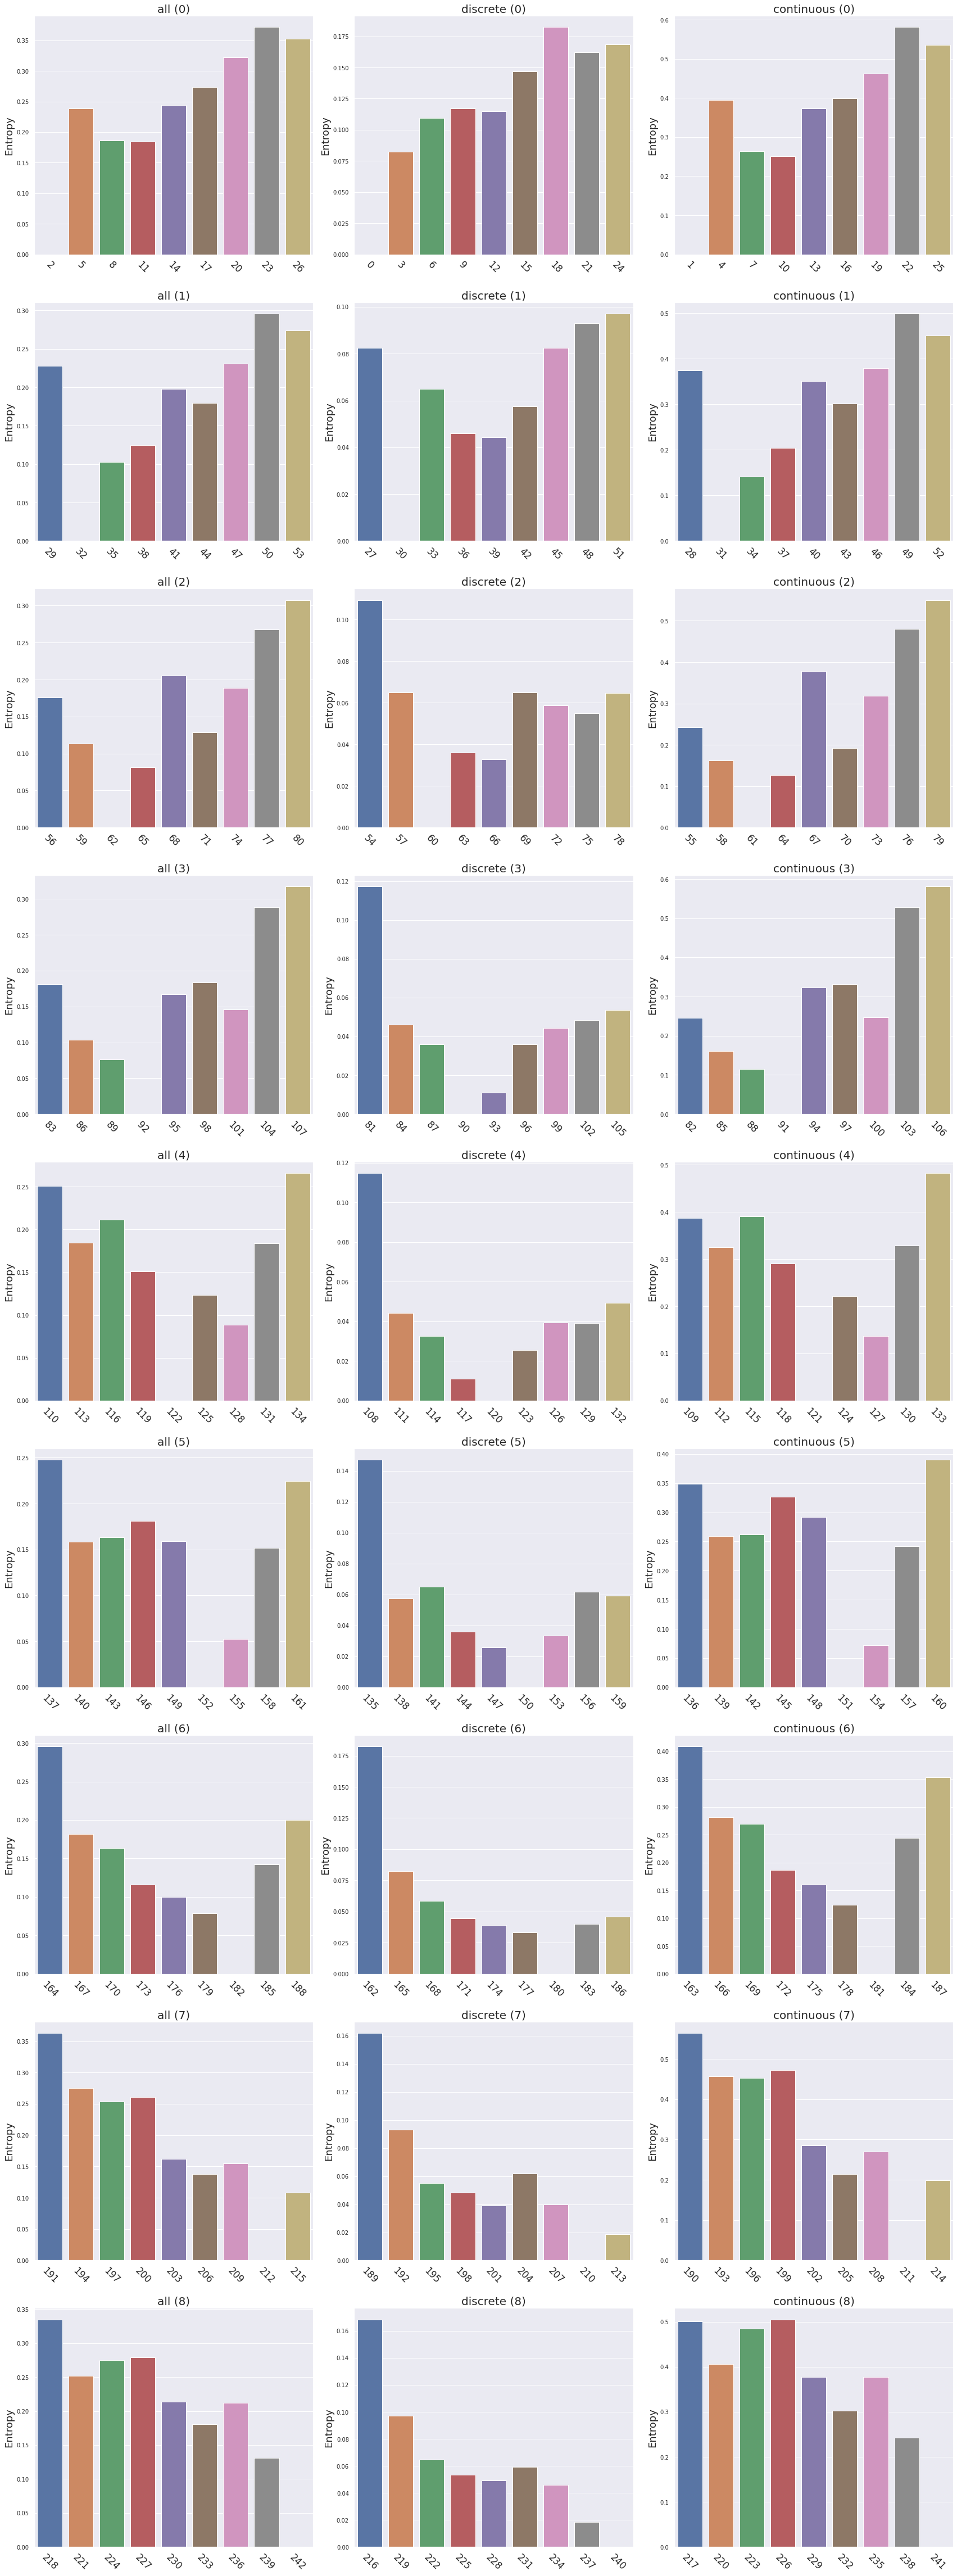

In [24]:
plt.style.use({'figure.figsize':(16, 6)})
fig,axes=plt.subplots(9,3,figsize=(24,64))
fig.subplots_adjust(hspace=40)
measure = 'Entropy'
for i in range(9):
    for j in range(3):
        distance_kind = ['all','discrete','continuous']
        df_tmp = df_distance[(df_distance['G1']==i) & (df_distance['D']==distance_kind[j])]        
        ax = sns.barplot(x=df_tmp.index, y=df_tmp[measure],data=df_tmp,ax=axes[i,j])
        ax.set_title('%s (%d)'%(distance_kind[j],i),fontsize=20)
        #ax.tick_params(axis='x',labelsize=10)
        ax.tick_params(axis='y',labelsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=-45)
fig.tight_layout()

# 可视化特征

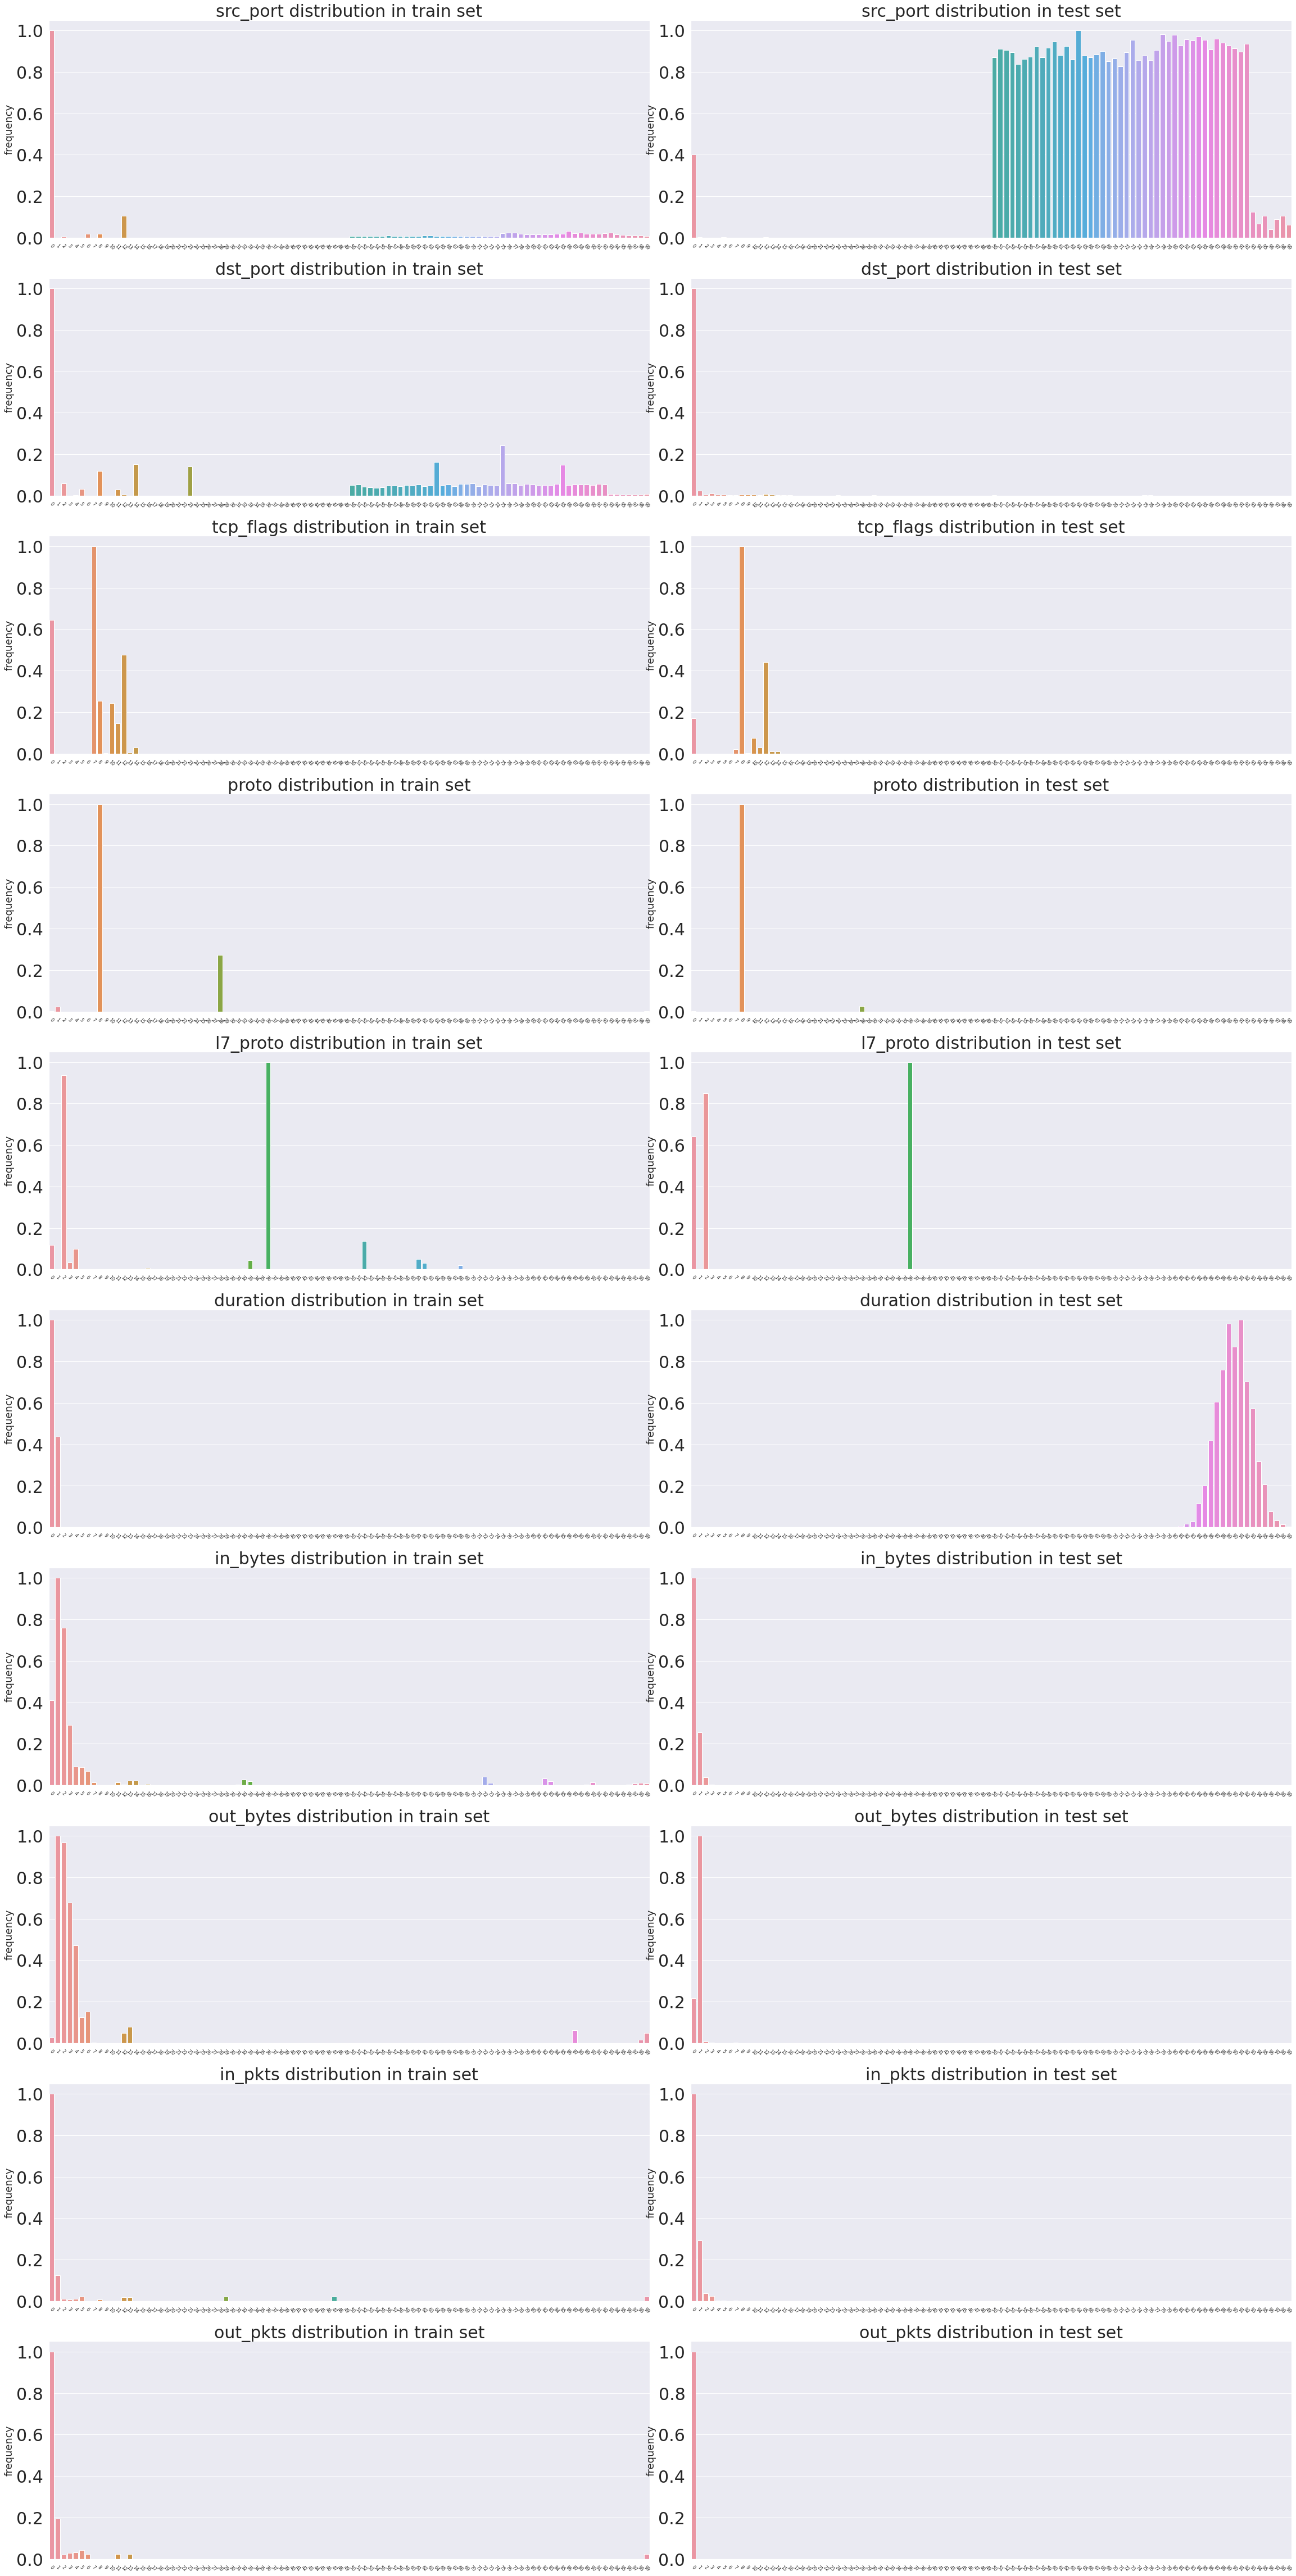

In [12]:
df_tmp1 = pd.read_csv("%s%s"%(g_test_path,"8.csv"),index_col=0)
df_tmp2 = pd.read_csv("%s%s"%(g_sample_path,"0.csv"),index_col=0)
df1,s1,df2,s2 = GetHistogram(df_tmp1,df_tmp2)
df1 = df1.T
df2 = df2.T

key_list = ['src_port','dst_port','tcp_flags','proto','l7_proto','duration','in_bytes','out_bytes','in_pkts','out_pkts']

plt.style.use({'figure.figsize':(16, 6)})
fig,axes=plt.subplots(len(key_list),2,figsize=(32,64))
fig.subplots_adjust(hspace=40)
row = 0
for key in key_list:
    ax = sns.barplot(x=df1.index, y=key,data=df1,ax=axes[row,0])
    ax.set_title('%s distribution in train set'%key,fontsize=30)
    ax.set_ylabel('frequency')
    ax.tick_params(axis='x',labelsize=8)
    ax.tick_params(axis='y',labelsize=30)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=-45)

    ax = sns.barplot(x=df2.index, y=key,data=df2,ax=axes[row,1])
    ax.set_title('%s distribution in test set'%key,fontsize=30)
    ax.set_ylabel('frequency')
    ax.tick_params(axis='x',labelsize=8)
    ax.tick_params(axis='y',labelsize=30)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=-45)
    
    row = row + 1
    
fig.tight_layout()